<a href="https://colab.research.google.com/github/salmamahmoud732/Machine_Task1/blob/main/Task1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ydata-profiling
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.8 MB/s eta 0:00:00


/tmp/ipykernel_5418/1189491407.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df['embarked'].fillna(df['embarked'].mode(), inplace=True)

In [6]:
df['age'].fillna(df['age'].median(), inplace=True)

In [7]:
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

In [8]:
df['embark_town'].fillna(df['embark_town'].mode(), inplace=True)

In [9]:
df['deck'].fillna(df['deck'].mode(), inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         204 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [11]:
if 'deck' in df.columns:
    df.drop('deck', axis=1, inplace=True)
else:
    print("'deck' column not found in the DataFrame.")

In [12]:
if 'class' in df.columns:
    df.drop('class', axis=1, inplace=True)
else:
    print("'class' column not found in the DataFrame.")

In [13]:
if 'embark_town' in df.columns:
    df.drop('embark_town', axis=1, inplace=True)
else:
    print("'embark_town' column not found in the DataFrame.")

In [14]:
if 'alive' in df.columns:
    df.drop('alive', axis=1, inplace=True)
else:
    print("'alive' column not found in the DataFrame.")

In [15]:
if 'alive' in df.columns:
    df.drop('alive', axis=1, inplace=True)
else:
    print("'alive' column not found in the DataFrame.")

'alive' column not found in the DataFrame.


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   embarked    891 non-null    object 
 8   who         891 non-null    object 
 9   adult_male  891 non-null    bool   
 10  alone       891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 64.5+ KB


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   embarked    891 non-null    object 
 8   who         891 non-null    object 
 9   adult_male  891 non-null    bool   
 10  alone       891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 64.5+ KB


In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    775 non-null    int64  
 1   pclass      775 non-null    int64  
 2   sex         775 non-null    object 
 3   age         775 non-null    float64
 4   sibsp       775 non-null    int64  
 5   parch       775 non-null    int64  
 6   fare        775 non-null    float64
 7   embarked    775 non-null    object 
 8   who         775 non-null    object 
 9   adult_male  775 non-null    bool   
 10  alone       775 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 62.1+ KB


In [20]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.331388,-0.078114,-0.037841,0.069864,0.247159,-0.529158,-0.176714
pclass,-0.331388,1.000000,-0.342745,0.087050,0.038998,-0.554649,0.069762,0.113778
age,-0.078114,-0.342745,1.000000,-0.279316,-0.182697,0.092503,0.274454,0.190270
sibsp,-0.037841,0.087050,-0.279316,1.000000,0.379535,0.133807,-0.272326,-0.607809
parch,0.069864,0.038998,-0.182697,0.379535,1.000000,0.190823,-0.345630,-0.569387
fare,0.247159,-0.554649,0.092503,0.133807,0.190823,1.000000,-0.164481,-0.245168
adult_male,-0.529158,0.069762,0.274454,-0.272326,-0.345630,-0.164481,1.000000,0.384923
alone,-0.176714,0.113778,0.190270,-0.607809,-0.569387,-0.245168,0.384923,1.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    775 non-null    int64  
 1   pclass      775 non-null    int64  
 2   sex         775 non-null    object 
 3   age         775 non-null    float64
 4   sibsp       775 non-null    int64  
 5   parch       775 non-null    int64  
 6   fare        775 non-null    float64
 7   embarked    775 non-null    object 
 8   who         775 non-null    object 
 9   adult_male  775 non-null    bool   
 10  alone       775 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 62.1+ KB


In [22]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
885,False,False,False,False,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,False,False,False,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False


In [23]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
who,0
adult_male,0


In [24]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
885,0,3,female,39.0,0,5,29.125,Q,woman,False,False
887,1,1,female,19.0,0,0,30.000,S,woman,False,True
888,0,3,female,28.0,1,2,23.450,S,woman,False,False
889,1,1,male,26.0,0,0,30.000,C,man,True,True
890,0,3,male,32.0,0,0,7.750,Q,man,True,True


In [25]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


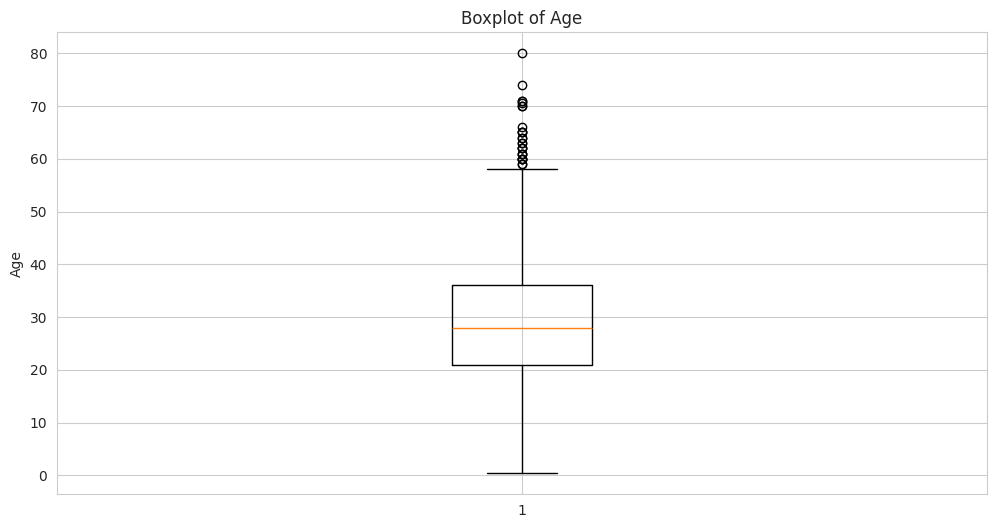

In [26]:
plt.boxplot(df['age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.show()

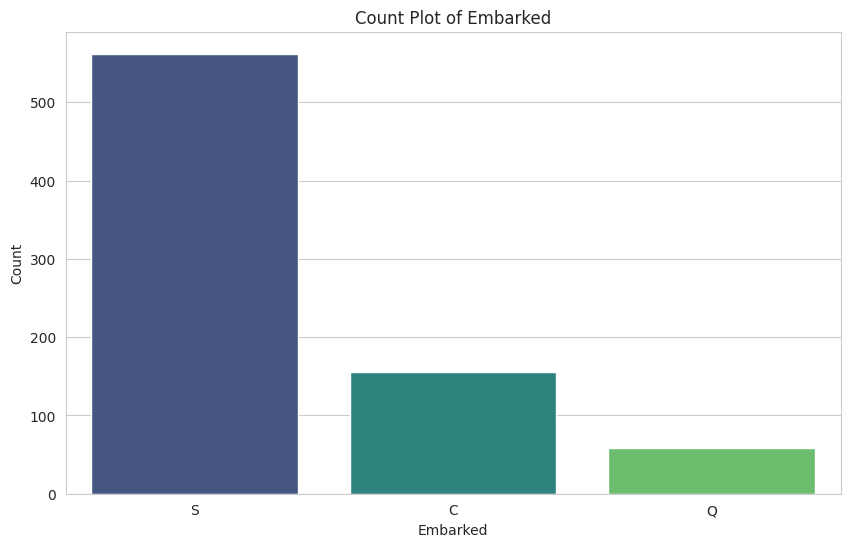

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='embarked', palette='viridis')
plt.title('Count Plot of Embarked')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    775 non-null    int64  
 1   pclass      775 non-null    int64  
 2   sex         775 non-null    object 
 3   age         775 non-null    float64
 4   sibsp       775 non-null    int64  
 5   parch       775 non-null    int64  
 6   fare        775 non-null    float64
 7   embarked    775 non-null    object 
 8   who         775 non-null    object 
 9   adult_male  775 non-null    bool   
 10  alone       775 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 62.1+ KB


In [29]:
df.shape

(775, 11)

In [30]:
categorical_cols = ['embarked', 'who']

# Filter out columns that don't exist in df to prevent KeyError on re-execution
existing_categorical_cols = [col for col in categorical_cols if col in df.columns]

if existing_categorical_cols:
    # Initialize OneHotEncoder
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Fit and transform the existing categorical columns
    encoded_features = ohe.fit_transform(df[existing_categorical_cols])

    # Create a DataFrame with the encoded features
    encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(existing_categorical_cols), index=df.index)

    # Concatenate the new DataFrame with the original one and drop the original categorical columns
    df = pd.concat([df, encoded_df], axis=1)
    df.drop(columns=existing_categorical_cols, inplace=True)

    print(f"Successfully encoded and dropped: {existing_categorical_cols}")
else:
    print("Categorical columns 'embarked', 'who' not found. Likely already processed.")

df.head()

Successfully encoded and dropped: ['embarked', 'who']


,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman
0,0,3,male,22.0,1,0,7.2500,True,False,0.0,0.0,1.0,0.0,1.0,0.0
1,1,1,female,38.0,1,0,71.2833,False,False,1.0,0.0,0.0,0.0,0.0,1.0
2,1,3,female,26.0,0,0,7.9250,False,True,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,female,35.0,1,0,53.1000,False,False,0.0,0.0,1.0,0.0,0.0,1.0
4,0,3,male,35.0,0,0,8.0500,True,True,0.0,0.0,1.0,0.0,1.0,0.0


In [31]:
if 'sex' in df.columns:
    le = LabelEncoder()
    df['sex'] = le.fit_transform(df['sex'])
    df.head()
else:
    print("'sex' column not found in the DataFrame. It might have been processed already.")
    df.head()

In [32]:
# Convert boolean columns to integer (0 or 1)
for col in ['adult_male', 'alone']:
    if col in df.columns and df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman
0,0,3,1,22.0,1,0,7.2500,1,0,0.0,0.0,1.0,0.0,1.0,0.0
1,1,1,0,38.0,1,0,71.2833,0,0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,3,0,26.0,0,0,7.9250,0,1,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,0,35.0,1,0,53.1000,0,0,0.0,0.0,1.0,0.0,0.0,1.0
4,0,3,1,35.0,0,0,8.0500,1,1,0.0,0.0,1.0,0.0,1.0,0.0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    775 non-null    int64  
 1   pclass      775 non-null    int64  
 2   sex         775 non-null    int64  
 3   age         775 non-null    float64
 4   sibsp       775 non-null    int64  
 5   parch       775 non-null    int64  
 6   fare        775 non-null    float64
 7   adult_male  775 non-null    int64  
 8   alone       775 non-null    int64  
 9   embarked_C  775 non-null    float64
 10  embarked_Q  775 non-null    float64
 11  embarked_S  775 non-null    float64
 12  who_child   775 non-null    float64
 13  who_man     775 non-null    float64
 14  who_woman   775 non-null    float64
dtypes: float64(8), int64(7)
memory usage: 96.9 KB


In [34]:
df.shape

(775, 15)

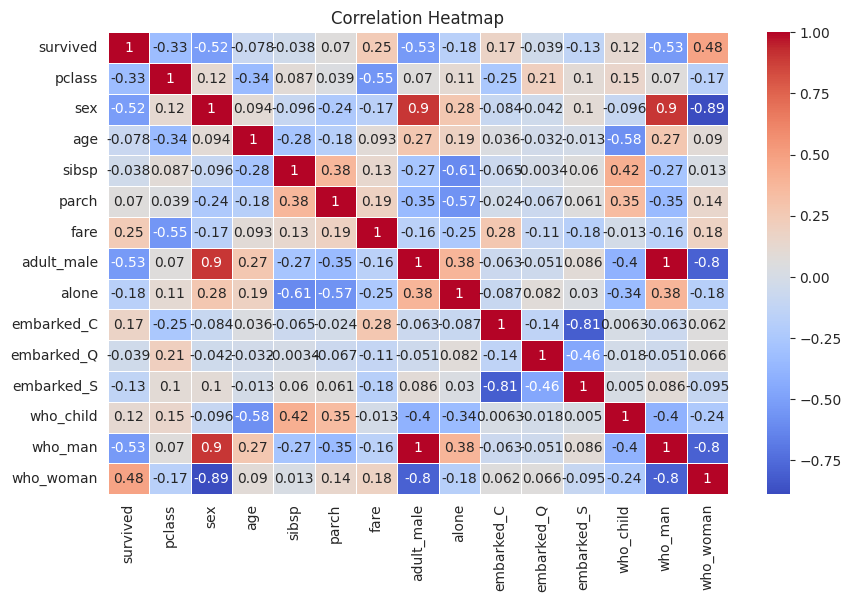

In [35]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [36]:
profie = ProfileReport(df , title = "Profile Report")

In [37]:
profie

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 49.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [38]:
profie

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    775 non-null    int64  
 1   pclass      775 non-null    int64  
 2   sex         775 non-null    int64  
 3   age         775 non-null    float64
 4   sibsp       775 non-null    int64  
 5   parch       775 non-null    int64  
 6   fare        775 non-null    float64
 7   adult_male  775 non-null    int64  
 8   alone       775 non-null    int64  
 9   embarked_C  775 non-null    float64
 10  embarked_Q  775 non-null    float64
 11  embarked_S  775 non-null    float64
 12  who_child   775 non-null    float64
 13  who_man     775 non-null    float64
 14  who_woman   775 non-null    float64
dtypes: float64(8), int64(7)
memory usage: 113.0 KB


In [40]:
import numpy as np

# Log Transform
df['fare'] = np.log1p(df['fare'])

In [41]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

models = {
    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        {
            "model__C":[0.01,0.1,1,10],
            "model__solver":["lbfgs","liblinear"]
        }
    ),

    "Decision Tree": (
        Pipeline([
            ("model",DecisionTreeClassifier(random_state=42))
        ]),
        {
            "model__max_depth":[3,5,7,10],
            "model__min_samples_split":[2,5,10],
            "model__criterion":["gini","entropy"]
        }
    ),

    "Random Forest": (
        Pipeline([
            ("model",RandomForestClassifier(random_state=42))
        ]),
        {
            "model__n_estimators":[100,200],
            "model__max_depth":[5,10,None],
            "model__min_samples_split":[2,5]
        }
    )
}

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", LogisticRegression(max_iter=1000))
])

In [44]:
param_grid = {
    "pca__n_components": [2, 4, 6, 8, 10],
    "model__C": [0.01, 0.1, 1, 10]
}

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", DecisionTreeClassifier())
])

In [46]:
param_grid = {
    "pca__n_components": [2, 4, 6, 8, 10],
    "model__C": [0.01, 0.1, 1, 10]
}

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", RandomForestClassifier())
])

In [48]:
param_grid = {
    "pca__n_components":[2,4,6,8,10],
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10,None],
    "model__min_samples_split":[2,5]
}

In [49]:
X_train_scaled = StandardScaler().fit_transform(X_train)

pca = PCA()
pca.fit(X_train_scaled)

PCA()

In [50]:
print("""
Logistic Regression is used as a baseline model.
It is simple, fast, and performs well on linearly separable data.
It is also easy to interpret.
""")


Logistic Regression is used as a baseline model.
It is simple, fast, and performs well on linearly separable data.
It is also easy to interpret.



In [51]:
print("""
Decision Tree can capture nonlinear relationships and interactions between features.
However, it may overfit the training data if the tree becomes too deep.
""")


Decision Tree can capture nonlinear relationships and interactions between features.
However, it may overfit the training data if the tree becomes too deep.



In [52]:
print("""
Random Forest combines many decision trees.
It usually provides better generalization, reduces overfitting,
and achieves higher accuracy than a single Decision Tree.
""")


Random Forest combines many decision trees.
It usually provides better generalization, reduces overfitting,
and achieves higher accuracy than a single Decision Tree.



In [53]:
results=[]

for name,(pipe,param_grid) in models.items():

    grid=GridSearchCV(
        pipe,
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train,y_train)

    best=grid.best_estimator_

    train_acc=best.score(X_train,y_train)
    test_acc=best.score(X_test,y_test)

    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "CV Accuracy": grid.best_score_,
        "Test Accuracy": test_acc,
        "Best Parameters": grid.best_params_
    })

    print("="*60)
    print(name)
    print("Best Parameters:",grid.best_params_)
    print("Train Accuracy:",round(train_acc,4))
    print("Test Accuracy:",round(test_acc,4))
    print("Cross Validation Accuracy:",grid.best_score_)

Logistic Regression
Best Parameters: {'model__C': 0.01, 'model__solver': 'lbfgs'}
Train Accuracy: 0.8016
Test Accuracy: 0.7742
Cross Validation Accuracy: 0.7999999999999999
Decision Tree
Best Parameters: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 2}
Train Accuracy: 0.8161
Test Accuracy: 0.8129
Cross Validation Accuracy: 0.8016129032258066
Random Forest
Best Parameters: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Train Accuracy: 0.8258
Test Accuracy: 0.8129
Cross Validation Accuracy: 0.7951612903225806


In [54]:
import pandas as pd

results_df=pd.DataFrame(results)

results_df

,Model,Train Accuracy,CV Accuracy,Test Accuracy,Best Parameters
0,Logistic Regression,0.801613,0.800000,0.774194,"{'model__C': 0.01, 'model__solver': 'lbfgs'}"
1,Decision Tree,0.816129,0.801613,0.812903,"{'model__criterion': 'gini', 'model__max_depth..."
2,Random Forest,0.825806,0.795161,0.812903,"{'model__max_depth': 5, 'model__min_samples_sp..."


In [55]:
best_model=results_df.loc[
    results_df["Test Accuracy"].idxmax()
]

print("="*60)
print("Best Model:",best_model["Model"])
print("Test Accuracy:",best_model["Test Accuracy"])
print("Best Parameters:",best_model["Best Parameters"])
print("Cross Validation Accuracy:",best_model["CV Accuracy"])

Best Model: Decision Tree
Test Accuracy: 0.8129032258064516
Best Parameters: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 2}
Cross Validation Accuracy: 0.8016129032258066


In [56]:
print("Best Model:", best_model["Model"])

Best Model: Decision Tree


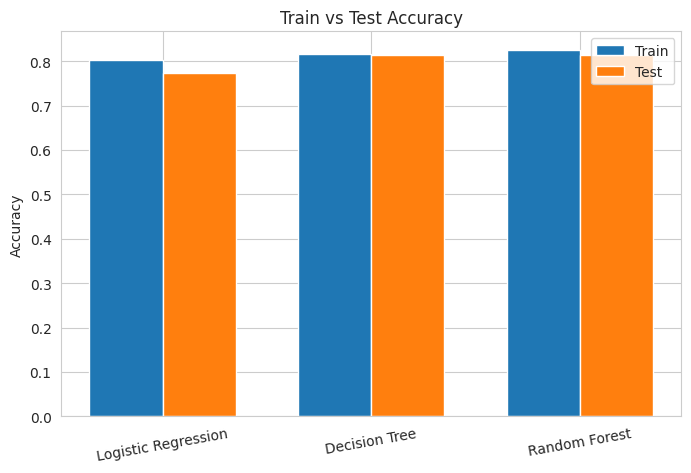

In [57]:
import matplotlib.pyplot as plt
import numpy as np

x=np.arange(len(results_df))

width=0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2,results_df["Train Accuracy"],width,label="Train")

plt.bar(x+width/2,results_df["Test Accuracy"],width,label="Test")

plt.xticks(x,results_df["Model"],rotation=10)

plt.ylabel("Accuracy")

plt.title("Train vs Test Accuracy")

plt.legend()

plt.show()

In [58]:
gap = best_model["Train Accuracy"] - best_model["Test Accuracy"]

print(f"Train Accuracy: {best_model['Train Accuracy']:.4f}")
print(f"Test Accuracy: {best_model['Test Accuracy']:.4f}")

if gap < 0.05:
    print("The model generalizes well and does not suffer from overfitting.")
elif gap < 0.10:
    print("The model shows slight overfitting.")
else:
    print("The model suffers from overfitting.")

Train Accuracy: 0.8161
Test Accuracy: 0.8129
The model generalizes well and does not suffer from overfitting.


In [59]:
for i,row in results_df.iterrows():

    gap=row["Train Accuracy"]-row["Test Accuracy"]

    print("="*50)
    print(row["Model"])

    if gap>0.10:
        print("Overfitting")
    elif row["Train Accuracy"]<0.75 and row["Test Accuracy"]<0.75:
        print("Underfitting")
    else:
        print("Good Generalization")

Logistic Regression
Good Generalization
Decision Tree
Good Generalization
Random Forest
Good Generalization


In [60]:
print(best_model)

Model                                                  Decision Tree
Train Accuracy                                              0.816129
CV Accuracy                                                 0.801613
Test Accuracy                                               0.812903
Best Parameters    {'model__criterion': 'gini', 'model__max_depth...
Name: 1, dtype: object


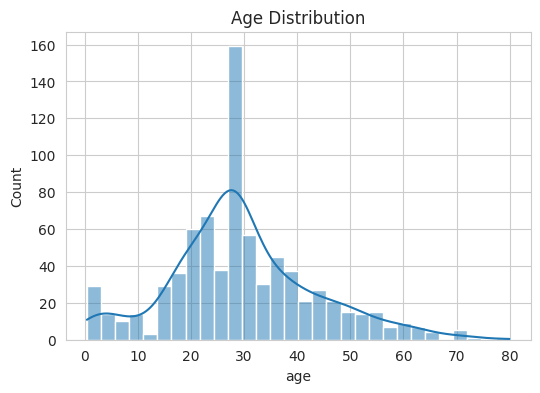

In [61]:
plt.figure(figsize=(6,4))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

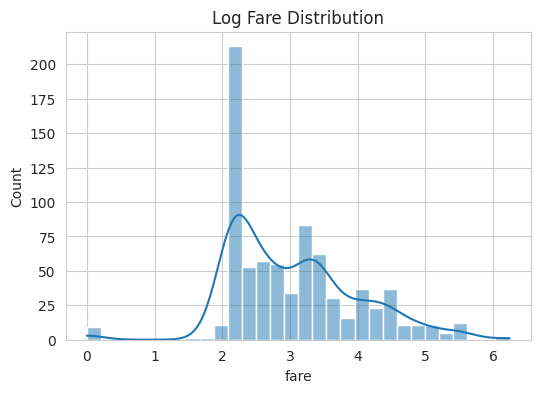

In [62]:
plt.figure(figsize=(6,4))

sns.histplot(df["fare"], bins=30, kde=True)

plt.title("Log Fare Distribution")

plt.show()

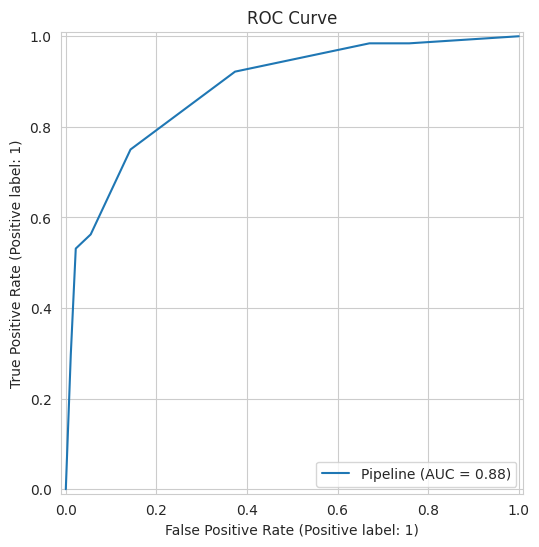

In [63]:
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Retrieve the model name and best parameters from the best_model Series
best_model_name = best_model["Model"]
best_model_params = best_model["Best Parameters"]

# Get the base pipeline for the best model from the 'models' dictionary
# The 'models' dictionary is defined in cell ysa3B1kh5IAX
base_pipeline = models[best_model_name][0]

# Set the best parameters on the base pipeline
final_best_estimator = base_pipeline.set_params(**best_model_params)

# Fit the final_best_estimator with the training data
final_best_estimator.fit(X_train, y_train)

RocCurveDisplay.from_estimator(
    final_best_estimator, # Use the fitted estimator from the previous cell
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

In [64]:
print("Best Model:", best_model["Model"])
print("Train Accuracy:", best_model["Train Accuracy"])
print("CV Accuracy:", best_model["CV Accuracy"])
print("Test Accuracy:", best_model["Test Accuracy"])
print("Best Parameters:", best_model["Best Parameters"])

Best Model: Decision Tree
Train Accuracy: 0.8161290322580645
CV Accuracy: 0.8016129032258066
Test Accuracy: 0.8129032258064516
Best Parameters: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 2}


In [65]:
from sklearn.metrics import classification_report

y_pred = final_best_estimator.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84        91
           1       0.79      0.75      0.77        64

    accuracy                           0.81       155
   macro avg       0.81      0.80      0.81       155
weighted avg       0.81      0.81      0.81       155

